# 03 · Embeddings — pretrained versus trained from scratch

The proposal's representation-level question: *in a small-corpus regime, do
pretrained embeddings or embeddings trained from scratch on the author corpus
better capture stylistic signal rather than general semantics?*

Two regimes:

| | trained on | dimension | knows |
|---|---|---|---|
| **from scratch** | this corpus' training split only | 200 | 19th-century literary Bangla, both registers |
| **BanglaBERT** | ~27 GB of modern Bangla | 768 | modern Bangla semantics |

Both are fit or applied **without ever seeing test text**: the skip-gram model
is trained on the training split alone.

The comparison is not just downstream accuracy. `style_vs_topic_score`
measures how well each representation separates *authors* versus how well it
separates *individual books* — a representation that mostly encodes topic
separates books much better than authors, because each book has its own
subject matter.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Bengali glyphs need a font that has them; fall back silently if absent.
for _f in ("Nirmala UI", "Vrinda", "Shonar Bangla", "Noto Sans Bengali"):
    try:
        matplotlib.font_manager.findfont(_f, fallback_to_default=False)
        plt.rcParams["font.family"] = _f
        break
    except Exception:
        continue
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.width", 160, "display.max_columns", 60)

from banglastylo import config
print("project root:", ROOT)

project root: E:\NLP Project\Bangla-author-fingerprinting


In [2]:
from banglastylo import corpus, splits, embeddings

passages = corpus.load_passages()
split = splits.load(passages)
Xtr, ytr = splits.xy(split.train)
Xva, yva = splits.xy(split.val)
Xte, yte = splits.xy(split.test)
works_te = [p.work for p in split.test]
print(f"train {len(Xtr)}  val {len(Xva)}  test {len(Xte)}")

train 1821  val 422  test 712


## 3.1 Skip-gram with negative sampling, from scratch

Written out in PyTorch rather than imported: `gensim` has no Python 3.14
wheel here, and writing it makes the training regime explicit — Mikolov
subsampling, a 3/4-power noise distribution, and a dynamic window radius.

In [3]:
w2v_path = config.MODELS / "w2v_scratch.npz"
if w2v_path.exists():
    w2v = embeddings.SkipGramWord2Vec.load(w2v_path)
    print(f"loaded cached model: {len(w2v.index_to_word):,} words × "
          f"{w2v.vectors.shape[1]}d")
else:
    w2v = embeddings.SkipGramWord2Vec()
    w2v.fit(Xtr)
    w2v.save(w2v_path)
print("vocabulary:", f"{len(w2v.index_to_word):,}")

loaded cached model: 9,414 words × 200d
vocabulary: 9,414


### Does it look like it learned Bangla?

Nearest neighbours for a few probe words. Function words should attract other
function words, register markers should attract their own register — that is
the property the stylometric use of these vectors depends on.

In [4]:
probes = ["তাহার", "করিয়া", "মানুষ", "রাজা", "কহিলেন", "হইল", "নারী", "গ্রাম"]
for p in probes:
    nb = w2v.most_similar(p, k=6)
    if nb:
        print(f"{p:10s} → " + ", ".join(f"{w} ({s:.2f})" for w, s in nb))
    else:
        print(f"{p:10s} → (out of vocabulary)")

তাহার      → উত্তেজনা (0.61), পলকের (0.59), প্রতিবেশীর (0.59), অপূর্ব্বর (0.58), খেলিয়া (0.58), জানিতেও (0.57)
করিয়া     → হইয়া (0.60), করিলেন (0.59), ডাকাইয়া (0.57), করিল (0.57), তাহাকে (0.56), আনিলেন (0.56)
মানুষ      → রূপদক্ষ (0.55), ছেলেও (0.55), রাখেনি (0.55), প্রতীক (0.54), ghoul (0.53), রহস্যময় (0.53)
রাজা       → সিতাব (0.64), মন্ত্রী (0.53), হিন্দুরাজ্য (0.53), রাজসভায় (0.51), রাজার (0.49), প্রদেশের (0.49)
কহিলেন     → সহাস্যে (0.70), শিরোমণিমশাই (0.70), হাসিমুখে (0.69), ডাক্তার (0.68), স্নিগ্ধকণ্ঠে (0.68), হাসিলেন (0.67)
হইল        → হইলেন (0.66), আরব্ধ (0.63), আহ্লাদসাগরে (0.61), অনতিবিলম্বে (0.59), সন্নিবেশিত (0.59), উপস্থিত (0.59)
নারী       → কোন্খানে (0.61), উদ্ধারের (0.61), নতশিরে (0.60), রহে (0.58), হেরিয়া (0.58), চাহ (0.58)
গ্রাম      → গ্রামখানি (0.62), অট্টালিকা (0.61), কুঠি (0.57), জঙ্গল (0.56), রেশমের (0.55), লুঠিয়া (0.49)


## 3.2 Pretrained BanglaBERT, frozen

In [5]:
import numpy as np

bert_cache = config.MODELS / "banglabert_vectors.npz"
if bert_cache.exists():
    d = np.load(bert_cache)
    Btr, Bva, Bte = d["train"], d["val"], d["test"]
    print("loaded cached BanglaBERT vectors")
else:
    enc = embeddings.BanglaBertEmbedder()
    print("encoding train…"); Btr = enc.encode(Xtr, verbose=True)
    print("encoding val…");   Bva = enc.encode(Xva)
    print("encoding test…");  Bte = enc.encode(Xte, verbose=True)
    np.savez_compressed(bert_cache, train=Btr, val=Bva, test=Bte)
    del enc
print("BanglaBERT passage vectors:", Btr.shape, Bva.shape, Bte.shape)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  443MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraModel LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


encoding train…


...

encoding test…


    encoded 16/712


    encoded 336/712


    encoded 656/712


BanglaBERT passage vectors: (1821, 768) (422, 768) (712, 768)


## 3.3 Pooling word vectors into passage vectors

SIF weighting (`a / (a + p(w))`) damps frequent words. For a *semantic* task
that helps; for a *stylometric* one it is a real trade-off, because the
frequent function words SIF damps are exactly what classical stylometry
relies on. Both poolings are computed so the report can show the difference
instead of assuming it.

In [6]:
Wtr_sif = embeddings.average_vectors(Xtr, w2v, weighting="sif")
Wva_sif = embeddings.average_vectors(Xva, w2v, weighting="sif")
Wte_sif = embeddings.average_vectors(Xte, w2v, weighting="sif")

Wtr_mean = embeddings.average_vectors(Xtr, w2v, weighting="mean")
Wva_mean = embeddings.average_vectors(Xva, w2v, weighting="mean")
Wte_mean = embeddings.average_vectors(Xte, w2v, weighting="mean")

np.savez_compressed(config.MODELS / "w2v_vectors.npz",
                    train_sif=Wtr_sif, val_sif=Wva_sif, test_sif=Wte_sif,
                    train_mean=Wtr_mean, val_mean=Wva_mean, test_mean=Wte_mean)
print("scratch-embedding passage vectors:", Wtr_sif.shape)

scratch-embedding passage vectors: (1821, 200)


## 3.4 Style or topic? The diagnostic

Two silhouette scores on the same vectors: one with authors as labels, one
with individual works as labels. The **ratio** is the quantity the proposal's
question turns on.

In [7]:
diag = {}
for name, V in [("scratch-w2v (SIF)",  Wte_sif),
                ("scratch-w2v (mean)", Wte_mean),
                ("BanglaBERT (frozen)", Bte)]:
    diag[name] = embeddings.style_vs_topic_score(V, yte, works_te)

diag_df = pd.DataFrame(diag).T
diag_df.to_csv(config.TABLES / "style_vs_topic.csv")
diag_df

,silhouette_author,silhouette_work,style_topic_ratio
scratch-w2v (SIF),0.263709,0.320021,0.824037
scratch-w2v (mean),0.254714,0.320172,0.795551
BanglaBERT (frozen),0.142582,0.201138,0.708879


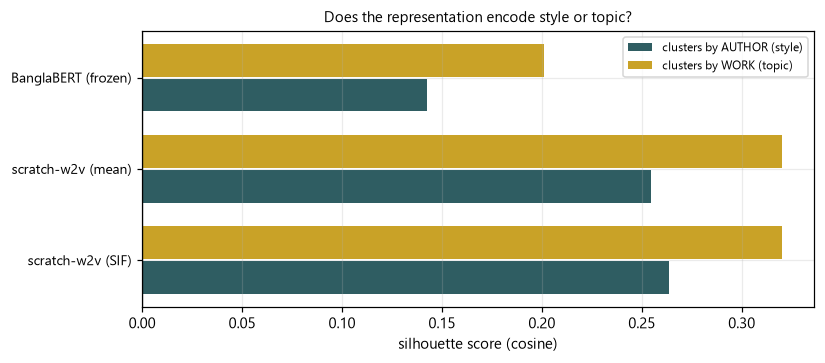

In [8]:
fig, ax = plt.subplots(figsize=(7.6, 3.4))
y = np.arange(len(diag_df))
ax.barh(y - 0.19, diag_df["silhouette_author"], height=0.36,
        label="clusters by AUTHOR (style)", color="#2F5D62")
ax.barh(y + 0.19, diag_df["silhouette_work"], height=0.36,
        label="clusters by WORK (topic)", color="#C9A227")
ax.set_yticks(y, diag_df.index, fontsize=9)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("silhouette score (cosine)")
ax.set_title("Does the representation encode style or topic?", fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(config.FIGURES / "style_vs_topic.png", dpi=200)
fig.savefig(config.REPORT_FIGURES / "style_vs_topic.png", dpi=200)
plt.show()

## 3.5 What the embedding spaces look like

PCA to two dimensions, coloured by author. Not evidence on its own — PCA
discards most of the variance — but it makes the difference between the two
regimes visible at a glance.

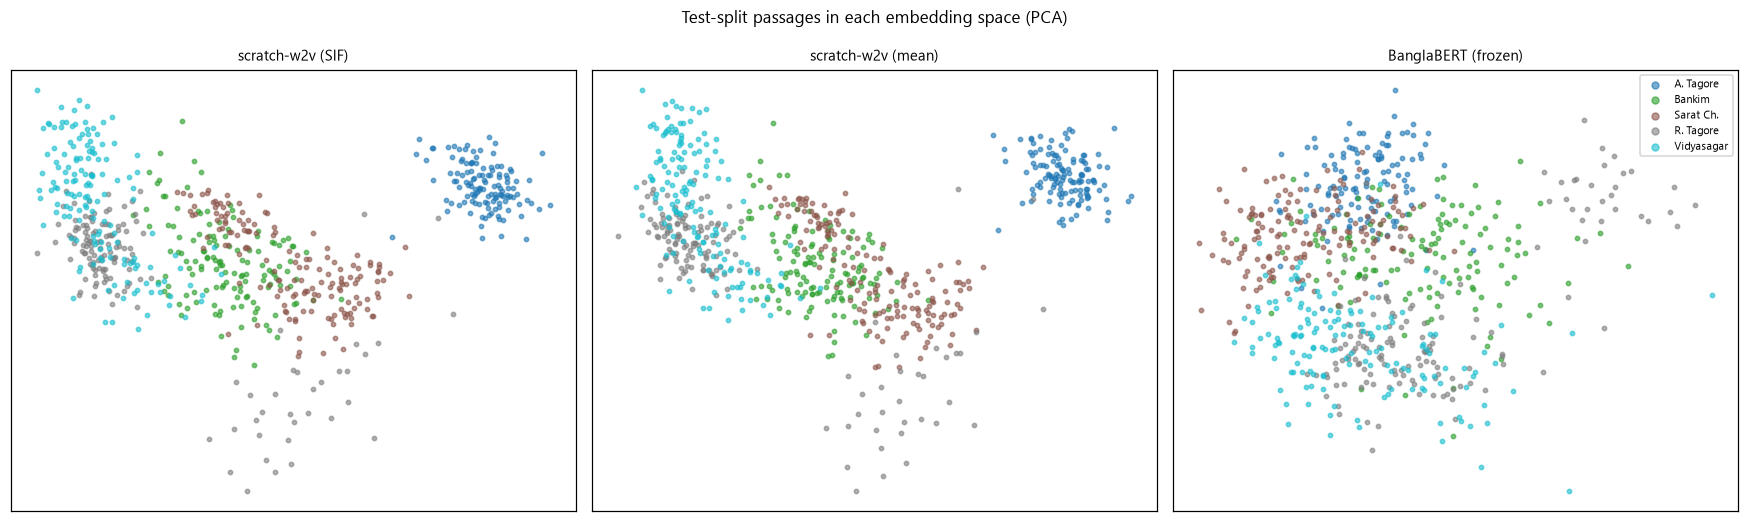

In [9]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
order = sorted(set(yte))
colours = plt.cm.tab10(np.linspace(0, 1, len(order)))

for ax, (name, V) in zip(axes, [("scratch-w2v (SIF)", Wte_sif),
                                ("scratch-w2v (mean)", Wte_mean),
                                ("BanglaBERT (frozen)", Bte)]):
    P = PCA(n_components=2, random_state=config.SEED).fit_transform(V)
    for a, c in zip(order, colours):
        m = np.array(yte) == a
        ax.scatter(P[m, 0], P[m, 1], s=8, alpha=0.6, color=c,
                   label=config.AUTHORS[a]["short"])
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
axes[-1].legend(fontsize=7, markerscale=1.6, loc="best")
fig.suptitle("Test-split passages in each embedding space (PCA)", fontsize=11)
fig.tight_layout()
fig.savefig(config.FIGURES / "embedding_pca.png", dpi=200)
fig.savefig(config.REPORT_FIGURES / "embedding_pca.png", dpi=200)
plt.show()